In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pennylane as qml

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch device:", device)
print("PennyLane version:", qml.__version__)


PyTorch device: cuda
PennyLane version: 0.45.1


In [ ]:
data = load_breast_cancer()

X = data.data.astype(np.float32)

y = (data.target == 0).astype(np.float32)

print("X shape:", X.shape)
print("Benign:", np.sum(y == 0))
print("Malignant:", np.sum(y == 1))


X shape: (569, 30)
Benign: 357
Malignant: 212


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

N_QUBITS = 4

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_angles = np.pi * np.tanh(X_train_pca)
X_test_angles = np.pi * np.tanh(X_test_pca)

print("Original features:", X_train.shape[1])
print("Quantum features:", X_train_angles.shape[1])
print("Explained variance by 4 PCs:",
      pca.explained_variance_ratio_.sum())
print("Individual explained variance:",
      pca.explained_variance_ratio_)


Original features: 30
Quantum features: 4
Explained variance by 4 PCs: 0.7931719
Individual explained variance: [0.44593522 0.18545255 0.09584641 0.06593768]


In [ ]:
X_train_t = torch.tensor(X_train_angles, dtype=torch.float32)
X_test_t = torch.tensor(X_test_angles, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_t.shape, y_train_t.shape)


torch.Size([455, 4]) torch.Size([455, 1])


In [ ]:
N_QVAF_QUBITS = 2
QVAF_LAYERS = 2

qvaf_dev = qml.device(
    "default.qubit",
    wires=N_QVAF_QUBITS
)

@qml.qnode(qvaf_dev, interface="torch", diff_method="backprop")
def qvaf_circuit(x, weights):
    for wire in range(N_QVAF_QUBITS):
        qml.RY(x, wires=wire)

    for layer in range(QVAF_LAYERS):
        for wire in range(N_QVAF_QUBITS):
            qml.Rot(
                weights[layer, wire, 0],
                weights[layer, wire, 1],
                weights[layer, wire, 2],
                wires=wire
            )

        qml.CNOT(wires=[0, 1])

    return qml.expval(qml.PauliZ(0))


test_weights = torch.randn(
    QVAF_LAYERS,
    N_QVAF_QUBITS,
    3,
    dtype=torch.float32
)

print("QVAF test output:", qvaf_circuit(
    torch.tensor(0.5),
    test_weights
))


QVAF test output: tensor(0.8293, dtype=torch.float64)


In [ ]:
class QVAF(nn.Module):
    def __init__(
        self,
        n_qubits=N_QVAF_QUBITS,
        n_layers=QVAF_LAYERS
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.weights = nn.Parameter(
            0.1 * torch.randn(
                n_layers,
                n_qubits,
                3,
                dtype=torch.float32
            )
        )

    def forward(self, x):
        outputs = []

        for value in x:
            outputs.append(qvaf_circuit(value, self.weights))

        return torch.stack(outputs).view(-1, 1)


In [ ]:
class QKANLayer(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        n_qubits=N_QVAF_QUBITS,
        n_layers=QVAF_LAYERS
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.qvafs = nn.ModuleList([
            nn.ModuleList([
                QVAF(n_qubits, n_layers)
                for _ in range(in_features)
            ])
            for _ in range(out_features)
        ])

        self.edge_scale = nn.Parameter(
            0.5 * torch.randn(out_features, in_features)
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

    def forward(self, x):
        # x: [batch, in_features]
        batch_outputs = []

        for j in range(self.out_features):
            terms = []

            for i in range(self.in_features):
                q_value = self.qvafs[j][i](x[:, i])
                terms.append(
                    self.edge_scale[j, i] * q_value
                )

            y_j = torch.cat(terms, dim=1).sum(dim=1)
            y_j = y_j + self.bias[j]
            batch_outputs.append(y_j)

        return torch.stack(batch_outputs, dim=1)


In [8]:
class QKANClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.qkan1 = QKANLayer(
            in_features=4,
            out_features=3,
            n_qubits=N_QVAF_QUBITS,
            n_layers=QVAF_LAYERS
        )

        self.qkan2 = QKANLayer(
            in_features=3,
            out_features=1,
            n_qubits=N_QVAF_QUBITS,
            n_layers=QVAF_LAYERS
        )

    def forward(self, x):
        x = self.qkan1(x)
        x = self.qkan2(x)
        return x


model = QKANClassifier()

total_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(model)
print("\nTrainable parameters:", total_params)


QKANClassifier(
  (qkan1): QKANLayer(
    (qvafs): ModuleList(
      (0-2): 3 x ModuleList(
        (0-3): 4 x QVAF()
      )
    )
  )
  (qkan2): QKANLayer(
    (qvafs): ModuleList(
      (0): ModuleList(
        (0-2): 3 x QVAF()
      )
    )
  )
)

Trainable parameters: 199


In [9]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

EPOCHS = 100

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if epoch == 1 or epoch % 10 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            train_acc = (preds == y_train_t).float().mean().item()

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train Acc: {train_acc:.4f}"
        )


Epoch 001 | Loss: 0.8119 | Train Acc: 0.3824
Epoch 010 | Loss: 0.7073 | Train Acc: 0.5187
Epoch 020 | Loss: 0.6666 | Train Acc: 0.6000
Epoch 030 | Loss: 0.6410 | Train Acc: 0.6242
Epoch 040 | Loss: 0.6223 | Train Acc: 0.6505
Epoch 050 | Loss: 0.6061 | Train Acc: 0.6901
Epoch 060 | Loss: 0.5917 | Train Acc: 0.6967
Epoch 070 | Loss: 0.5788 | Train Acc: 0.7033
Epoch 080 | Loss: 0.5679 | Train Acc: 0.7099
Epoch 090 | Loss: 0.5586 | Train Acc: 0.7143
Epoch 100 | Loss: 0.5506 | Train Acc: 0.7187


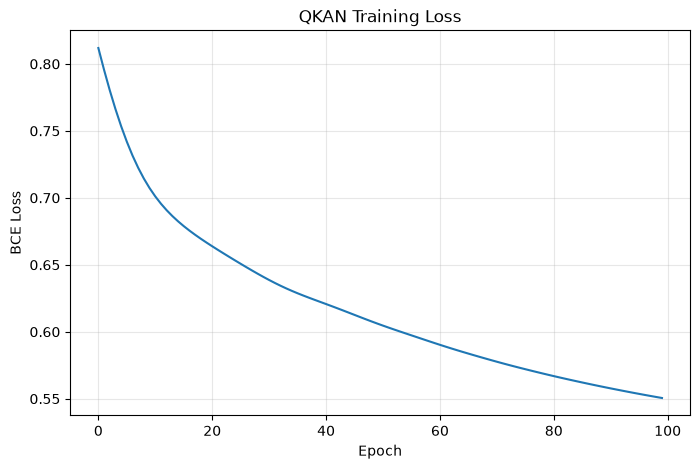

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("QKAN Training Loss")
plt.grid(alpha=0.3)
plt.show()


In [11]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits).numpy().ravel()

y_true = y_test.astype(int)
y_pred = (test_probs >= 0.5).astype(int)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, test_probs)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)


Accuracy : 0.7105
Precision: 0.6452
Recall   : 0.4762
F1-score : 0.5479
ROC-AUC  : 0.7054

Classification Report:
              precision    recall  f1-score   support

      Benign     0.7349    0.8472    0.7871        72
   Malignant     0.6452    0.4762    0.5479        42

    accuracy                         0.7105       114
   macro avg     0.6901    0.6617    0.6675       114
weighted avg     0.7019    0.7105    0.6990       114



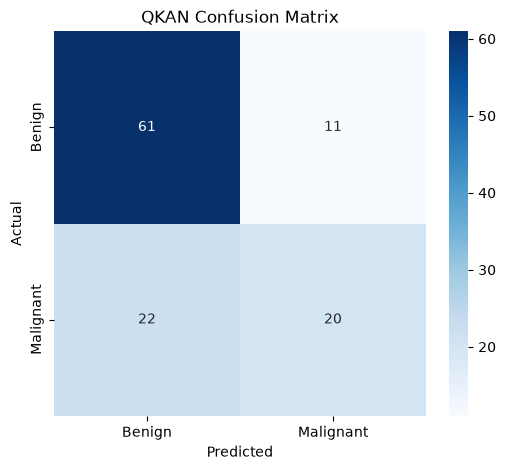

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QKAN Confusion Matrix")
plt.show()


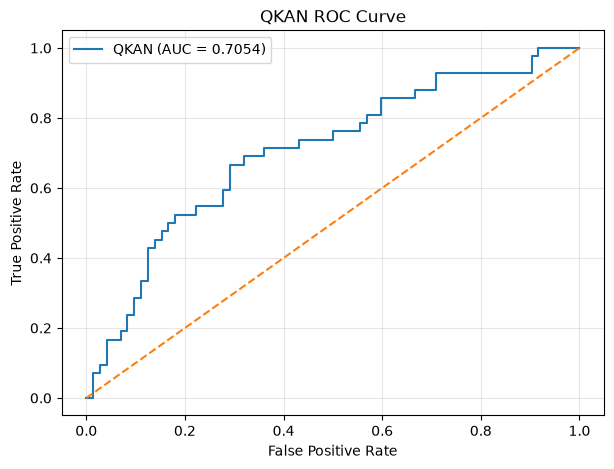

In [13]:
fpr, tpr, _ = roc_curve(y_true, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"QKAN (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("QKAN ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
